In [2]:
import re
from dataclasses import dataclass
import tldextract
import orjson
import json
from clickhouse_connect import get_client
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing of the results data for each domain

Only needs to be performed once, to generate `df_minimized.csv`

In [8]:
DF_MINIMIZED_PATH = "../results/df_minimized.csv"

In [ ]:
client = get_client(host="localhost", port=8123, username='nis', password='nis')

query = """
    SELECT
        worker_id,
        run_uuid,
        domain,
        start,
        end,
        results
    FROM doech_results
    WHERE results not like '%"error":%'
    and results != 'null' \
"""

df_raw = client.query_df(query)

In [ ]:
def minimize_results(results):
    try:
        results_list = json.loads(results)
    except json.JSONDecodeError:
        print(f"Could not decode results: {results}")
        return []

    if not isinstance(results_list, list) or len(results_list) == 0:
        print("Results are empty!")
        return []

    minimized = []
    for item in results_list:
        req = item.get("requestInfo") or {}
        sec = item.get("securityInfo") or {}

        if not req or not sec:
            print("Req or seq not present!")
            continue

        entry = {
            "url":              req .get("url"),
            "timestamp":        req .get("timestamp"),
            "type":             req .get("type"),
            "usedEch":          sec .get("usedEch"),
            "usedPrivateDns":   sec .get("usedPrivateDns"),
        }

        minimized.append(entry)

    return json.dumps(minimized)

In [ ]:
df_min = df_raw.copy()
df_min["min_results"]  = df_min["results"].apply(minimize_results)
df_min = df_min.drop(columns=["results"])

df_min = df_min.rename(columns={"min_results": "results"})

df_min.to_csv(DF_MINIMIZED_PATH, index=False)

## Load df_minimized

In [4]:
df_min = pd.read_csv(DF_MINIMIZED_PATH)
df_min['results_parsed'] = df_min['results'].apply(lambda s: orjson.loads(s))

## Calculate scope stats

In [10]:
scope1_output = '../results/df_scope1.csv'
scope2_output = '../results/df_scope2.csv'
scope2_leaks_output = '../results/df_scope2_leaks.csv'
scope3_output = '../results/df_scope3.csv'
scope4_output = '../results/df_scope4.csv'

In [7]:
@dataclass
class Scope1Result:
    domain: str
    usedEch: bool
    usedPrivateDns: bool
scope1_results = []

for _, row in df_min.iterrows():
    domain = row["domain"]
    expected_url = f"https://{domain}/"
    results_df = pd.json_normalize(row["results_parsed"])

    main_frames = results_df[results_df["type"] == "main_frame"]
    if len(main_frames) == 0:
        print(f"No main_frames found for {domain}")
        continue

    first_main_frame = main_frames.iloc[0]

    if first_main_frame["url"] != expected_url:
        print(f"First main frame is not matching for {domain}")
        continue

    res = Scope1Result(
        domain=domain,
        usedEch=first_main_frame["usedEch"],
        usedPrivateDns=first_main_frame["usedPrivateDns"],
    )

    scope1_results.append(res)

df_scope1 = pd.DataFrame(scope1_results)
df_scope1.to_csv(scope1_output, index=False)
df_scope1.head()

,domain,usedEch,usedPrivateDns
0,velk365.live,True,True
1,velki.app,True,True
2,velki123.vip,True,True
3,velki2.com,True,True
4,velkicx123.live,True,True


In [9]:
@dataclass
class Scope2Result:
    domain: str
    usedNone: int = 0
    usedOnlyEch: int = 0
    usedOnlyPrivateDns: int = 0
    usedBoth: int = 0

scope2_results = []

for _, row in df_min.iterrows():
    domain = row["domain"]
    tranco_pld = tldextract.extract(domain).top_domain_under_public_suffix
    results_df = pd.json_normalize(row["results_parsed"])

    mfs = results_df[
        (results_df["type"] == "main_frame") &
        (results_df["url"].str.startswith(f"https://{domain}"))
    ]
    if mfs.empty:
        print(f"No main_frame for {domain}")
        continue

    def url_matches_pld(url):
        ext = tldextract.extract(url)
        return ext.top_domain_under_public_suffix == tranco_pld

    same_pld = results_df[results_df["url"].apply(url_matches_pld)]

    res = Scope2Result(domain=domain)
    for _, req in same_pld.iterrows():
        ech = bool(req["usedEch"])
        doh = bool(req["usedPrivateDns"])
        if ech and doh:
            res.usedBoth += 1
        elif ech:
            res.usedOnlyEch += 1
        elif doh:
            res.usedOnlyPrivateDns += 1
        else:
            res.usedNone += 1

    scope2_results.append(res)

df_scope2 = pd.DataFrame(scope2_results)
df_scope2.to_csv(scope2_output, index=False)
df_scope2.head()

,domain,usedNone,usedOnlyEch,usedOnlyPrivateDns,usedBoth
0,velk365.live,0,0,0,25
1,velki.app,0,0,0,25
2,velki123.vip,0,0,0,22
3,velki2.com,0,0,0,52
4,velkicx123.live,0,0,0,19


In [11]:
@dataclass
class HostnameAudit:
    domain: str             # The PLD (e.g., example.com)
    hostname: str           # The full failing hostname (e.g., api.example.com)
    subdomain_label: str    # The specific prefix (e.g., 'api', 'www', '(root)')
    request_count: int      # Total requests to this hostname

infrastructure_leaks = []

for _, row in df_min.iterrows():
    pld = row["domain"]

    results_df = pd.json_normalize(row["results_parsed"])
    if results_df.empty: 
        continue

    row_pld_extract = tldextract.extract(pld)
    row_pld = row_pld_extract.top_domain_under_public_suffix

    def is_same_pld(url):
        ext = tldextract.extract(url)
        return ext.top_domain_under_public_suffix == row_pld

    scope2_df = results_df[results_df["url"].apply(is_same_pld)]
    if scope2_df.empty: 
        continue

    # We analyze each unique hostname (e.g., "api.example.com") separately
    scope2_df["hostname"] = scope2_df["url"].apply(lambda x: tldextract.extract(x).fqdn)
    hostname_groups = scope2_df.groupby("hostname")

    for hostname, group in hostname_groups:
        ech_usage = group["usedEch"].sum()          
        doh_usage = group["usedPrivateDns"].sum()   
        total_reqs = len(group)

        # Identify SYSTEMATIC FAILURES
        # Logic: If ECH *never* worked (0), but DoH *did* work (>0),
        # it is a server config gap, not a network/timeout error.
        if ech_usage == 0 and doh_usage > 0:

            ext = tldextract.extract(hostname)

            label = ext.subdomain if ext.subdomain else "(root)"

            infrastructure_leaks.append(HostnameAudit(
                domain=pld,
                hostname=hostname,
                subdomain_label=label,
                request_count=total_reqs
            ))

df_leaks = pd.DataFrame(infrastructure_leaks)

# Group failures by the Parent Domain to find the "Leak Type"
domain_groups = df_leaks.groupby("domain")["subdomain_label"].apply(set)

total_leaking_domains = len(domain_groups)
root_failures = 0
partial_failures = 0

for domain, failures in domain_groups.items():
    # If the root itself is in the failure list, it's a Total Failure
    if "(root)" in failures:
        root_failures += 1
    else:
        # If root is NOT in the list, it implies Root was secure -> Partial Failure
        partial_failures += 1

print(f"--- Analysis of Scope 2 (Same-Domain) Leakage ---")
print(f"Total Domains with Leaks: {total_leaking_domains}")
print(f"Type A: Total Failure (Root Failed):      {root_failures} ({root_failures/total_leaking_domains:.2%})")
print(f"Type B: Partial Deployment (Root Secure): {partial_failures} ({partial_failures/total_leaking_domains:.2%})")

print("\n--- Top Subdomains Causing Partial Deployments ---")
partial_leak_domains = domain_groups[
    ~domain_groups.apply(lambda x: "(root)" in x)
].index

df_partial_only = df_leaks[df_leaks["domain"].isin(partial_leak_domains)]
print(df_partial_only["subdomain_label"].value_counts().head(15))

df_leaks.to_csv(scope2_leaks_output, index=False)
print("Saved scope 2 leaks.")

--- Analysis of Scope 2 (Same-Domain) Leakage ---
Total Domains with Leaks: 6505
Type A: Total Failure (Root Failed):      1298 (19.95%)
Type B: Partial Deployment (Root Secure): 5207 (80.05%)

--- Top Subdomains Causing Partial Deployments ---
subdomain_label
www          1677
cdn           392
api           221
icdn05        115
static        107
cdnstatic      78
images         70
img            69
sst            67
gtm            63
assets         56
media          54
analytics      51
ss             37
app            35
Name: count, dtype: int64
Saved scope 2 leaks.


In [13]:
@dataclass
class Scope3Result:
    domain: str
    usedNone: int = 0
    usedOnlyEch: int = 0
    usedOnlyPrivateDns: int = 0
    usedBoth: int = 0

scope3_results = []

for _, row in df_min.iterrows():
    domain = row["domain"]
    expected_url = f"https://{domain}/"
    results_df = pd.json_normalize(row["results_parsed"])

    mfs = results_df[(results_df["type"] == "main_frame")]
    if mfs.empty or mfs.iloc[0]["url"] != expected_url:
        print(f"No main_frame for {domain}")
        continue

    redirect_plds = {
        tldextract.extract(url).top_domain_under_public_suffix
        for url in mfs["url"]
        if tldextract.extract(url).top_domain_under_public_suffix
    }

    if not redirect_plds:
        continue

    def is_redirect_domain(url):
        ext = tldextract.extract(url)
        return ext.top_domain_under_public_suffix in redirect_plds

    redirect_reqs = results_df[results_df["url"].apply(is_redirect_domain)]

    res = Scope3Result(domain=domain)

    for _, req in redirect_reqs.iterrows():
        ech = bool(req["usedEch"])
        doh = bool(req["usedPrivateDns"])
        if ech and doh:
            res.usedBoth += 1
        elif ech:
            res.usedOnlyEch += 1
        elif doh:
            res.usedOnlyPrivateDns += 1
        else:
            res.usedNone += 1

    scope3_results.append(res)

df_scope3 = pd.DataFrame(scope3_results)
df_scope3.to_csv(scope3_output, index=False)
df_scope3.head()

,domain,usedNone,usedOnlyEch,usedOnlyPrivateDns,usedBoth
0,velk365.live,0,0,0,25
1,velki.app,0,0,0,25
2,velki123.vip,0,0,0,22
3,velki2.com,0,0,0,52
4,velkicx123.live,0,0,0,19


In [14]:
@dataclass
class Scope4Result:
    domain: str
    usedNone: int = 0
    usedOnlyEch: int = 0
    usedOnlyPrivateDns: int = 0
    usedBoth: int = 0

scope4_results = []

for _, row in df_min.iterrows():
    domain = row["domain"]
    expected_url = f"https://{domain}/"
    results_df = pd.json_normalize(row["results_parsed"])

    mfs = results_df[results_df["type"] == "main_frame"]
    if mfs.empty or mfs.iloc[0]["url"] != expected_url:
        print(f"No main_frame for {domain}")
        continue

    res = Scope4Result(domain=domain)

    for _, req in results_df.iterrows():
        ech = bool(req["usedEch"])
        doh = bool(req["usedPrivateDns"])
        if ech and doh:
            res.usedBoth += 1
        elif ech:
            res.usedOnlyEch += 1
        elif doh:
            res.usedOnlyPrivateDns += 1
        else:
            res.usedNone += 1

    scope4_results.append(res)

df_scope4 = pd.DataFrame(scope4_results)
df_scope4.to_csv(scope4_output, index=False)
df_scope4.head()

,domain,usedNone,usedOnlyEch,usedOnlyPrivateDns,usedBoth
0,velk365.live,1,0,38,26
1,velki.app,0,0,28,25
2,velki123.vip,0,0,9,22
3,velki2.com,1,0,23,52
4,velkicx123.live,0,0,14,19


## Visualize the results

In [15]:
df_scope1 = pd.read_csv(scope1_output)
df_scope2 = pd.read_csv(scope2_output)
df_scope3 = pd.read_csv(scope3_output)
df_scope4 = pd.read_csv(scope4_output)

### Leakage across scopes

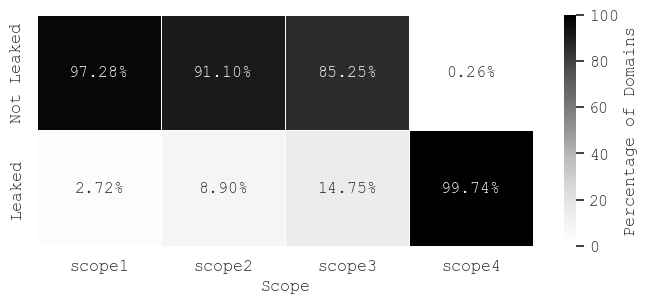

In [19]:
scope1_leak = ~(df_scope1['usedEch'] & df_scope1['usedPrivateDns'])

def domain_leak_bool(df):
    total = df[['usedNone','usedOnlyEch','usedOnlyPrivateDns','usedBoth']].sum(axis=1)
    all_both = df['usedBoth'] == total
    return ~all_both

scope2_leak = domain_leak_bool(df_scope2)
scope3_leak = domain_leak_bool(df_scope3)
scope4_leak = domain_leak_bool(df_scope4)

leak_perc = pd.DataFrame({
    'scope1': [(1 - scope1_leak.mean()) * 100, scope1_leak.mean() * 100],
    'scope2': [(1 - scope2_leak.mean()) * 100, scope2_leak.mean() * 100],
    'scope3': [(1 - scope3_leak.mean()) * 100, scope3_leak.mean() * 100],
    'scope4': [(1 - scope4_leak.mean()) * 100, scope4_leak.mean() * 100],
}, index=['Not Leaked', 'Leaked'])

annot_perc = leak_perc.map(lambda x: f"{x:.2f}%")

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Courier New', 'DejaVu Sans Mono', 'monospace']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.figure(figsize=(8, 3), facecolor='white')

sns.set_theme(
    style="white",
    rc={
        'font.family': 'monospace',
        'font.size': 12,
        'axes.labelsize': 12,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'pdf.fonttype': 42,  # Force TrueType fonts for PDF
        'ps.fonttype': 42
    }
)

ax = sns.heatmap(
    leak_perc,
    annot=annot_perc.to_numpy(),
    fmt="",
    cmap="Greys",
    vmin=0, vmax=100,
    cbar_kws={'label': 'Percentage of Domains'},
    linewidths=0.5,
    annot_kws={"family": "monospace", "size": 12}
)

ax.set_ylabel("")
ax.set_xlabel("Scope", fontfamily='monospace', fontsize=12)
plt.xticks(fontfamily='monospace')
plt.yticks(fontfamily='monospace')

plt.savefig("doech-leakage.pdf", format="pdf", bbox_inches="tight", facecolor='white')
plt.show()

### Leakage reasons across scopes

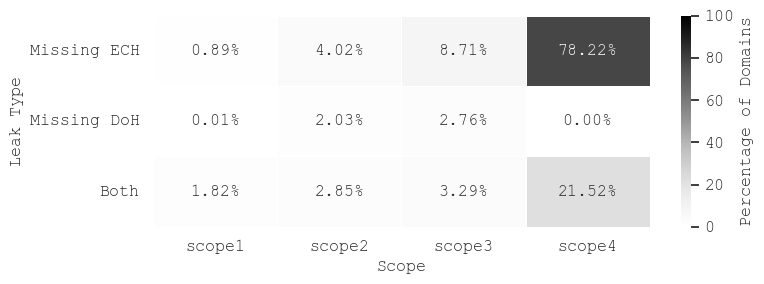

In [20]:
def leak_buckets(df, is_scope1=False):
    """
    Returns a dict with fractions of domains in each exclusive leak bucket:
      - 'ECH_only_leak'
      - 'DoH_only_leak'
      - 'Both_leak'
    """
    if is_scope1:
        ech = df['usedEch'].astype(bool)
        doh = df['usedPrivateDns'].astype(bool)
        no_ech = ~ech
        no_doh = ~doh
    else:
        no_ech = (df['usedNone'] + df['usedOnlyPrivateDns']) > 0
        no_doh = (df['usedNone'] + df['usedOnlyEch']) > 0

    ech_only   = ( no_ech & ~no_doh ).mean()
    doh_only   = (~no_ech &  no_doh ).mean()
    both_leak  = ( no_ech &  no_doh ).mean()

    return {
        'Missing ECH':  ech_only,
        'Missing DoH':  doh_only,
        'Both':      both_leak,
    }

b1 = leak_buckets(df_scope1, is_scope1=True)
b2 = leak_buckets(df_scope2)
b3 = leak_buckets(df_scope3)
b4 = leak_buckets(df_scope4)

leak_df = pd.DataFrame({
    'scope1': b1,
    'scope2': b2,
    'scope3': b3,
    'scope4': b4,
})

leak_df_perc = leak_df * 100

annot_perc = leak_df_perc.map(lambda x: f"{x:.2f}%")

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Courier New', 'DejaVu Sans Mono', 'monospace']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sns.set_theme(
    style="white",
    rc={
       'font.family': 'monospace',
        'font.size': 12,
        'axes.labelsize': 12,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'pdf.fonttype': 42,  # Force TrueType fonts for PDF
        'ps.fonttype': 42
    }
)

plt.figure(figsize=(8, 3))
ax = sns.heatmap(
    leak_df_perc,
    annot=annot_perc.to_numpy(),
    fmt="",
    cmap="Greys",
    vmin=0, vmax=100,
    cbar_kws={'label': 'Percentage of Domains'},
    linewidths=0.5,
    annot_kws={"family": "monospace", "size": 12}
)

ax.set_xlabel("Scope", fontfamily='monospace', fontsize=12)
ax.set_ylabel("Leak Type", fontfamily='monospace', fontsize=12)
plt.xticks(fontfamily='monospace')
plt.yticks(fontfamily='monospace')
plt.tight_layout()

plt.savefig("doech-leakage-reasons.pdf", format="pdf", bbox_inches="tight")
plt.show()